# 07 · Selección con validación temporal

Lección del segundo envío: XGBoost dio F1 0,747 en la partición aleatoria y 0,7045 en Kaggle, por debajo del baseline (0,707) que había elegido todo en diciembre. La partición aleatoria mezcla meses y deja la misma obligación en train y test; el modelo memoriza obligaciones que en enero no se repiten. Aquí todo se decide con **validación temporal**: tres cortes (medir en octubre, noviembre y diciembre entrenando con los meses previos) y el promedio de F1 como criterio.

1. Datos · 2. Cortes temporales · 3. Validación adversaria (diciembre frente a enero) · 4. LightGBM con Optuna temporal · 5. XGBoost con Optuna temporal · 6. Peso por recencia · 7. Ensamble y umbrales en diciembre · 8. Modelo final y Kaggle

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
import xgboost as xgb
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore"); optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.width", 200, "display.max_columns", 60)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; PROC = DATA / "processed"; OUT = ROOT / "outputs"; (ROOT / "models").mkdir(exist_ok=True)
C_BLUE, C_ORANGE, C_AQUA, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea",
                     "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42; NJ = 6
import sys; sys.path.insert(0, str(ROOT / "src"))
from tracking import grupo, registrar_busqueda, registrar_final, anexar, resumen
import mlflow
def busquedas_previas(grupo_nombre, minimo):
    "Si MLflow ya tiene al menos `minimo` búsquedas del grupo, devuelve (params del mejor, DataFrame). Si no, None."
    mlflow.set_tracking_uri(__import__("tracking").TRACKING_URI)
    df = mlflow.search_runs(experiment_names=["opciones_pago"], filter_string=f"tags.grupo = '{grupo_nombre}' and tags.tipo = 'busqueda'")
    if len(df) < minimo: return None
    best = df.sort_values("metrics.f1_val", ascending=False).iloc[0]
    params = {c[7:]: best[c] for c in df.columns if c.startswith("params.") and isinstance(best[c], str)}
    return params, df
def tipar(params, enteros):
    return {k: (int(float(v)) if k in enteros else float(v)) for k, v in params.items()}
TAGS = {"notebook": "07_validacion_temporal", "validacion": "temporal_3_cortes", "particion": "train<=t-1 / val t, t in {oct,nov,dic}", "busqueda": "optuna_tpe"}

## 1. Datos

Dataset ampliado del notebook 06 (77 variables seleccionadas + 23 nuevas = 100).

In [2]:
train = pd.read_parquet(PROC / "train_fe.parquet"); test = pd.read_parquet(PROC / "test_fe.parquet")
FEATS = pd.read_csv(PROC / "features_fe.csv").feature.tolist(); TARGET = "var_rpta_alt"
CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
for c in CAT:
    cats = pd.api.types.union_categoricals([train[c], test[c]]).categories
    train[c] = pd.Categorical(train[c], categories=cats); test[c] = pd.Categorical(test[c], categories=cats)
y = train[TARGET]; mes = train.fecha_var_rpta_alt
print(f"train {train.shape[0]:,} | test {test.shape[0]:,} | variables {len(FEATS)} ({len(CAT)} categóricas)")

def mejor_umbral(y_true, p):
    grid = np.arange(0.20, 0.81, 0.01); f1s = [f1_score(y_true, p >= u) for u in grid]; return float(grid[int(np.argmax(f1s))]), float(max(f1s))
def metricas(y_true, p, u):
    pred = (p >= u).astype(int)
    return {"umbral": u, "AUC": roc_auc_score(y_true, p), "F1": f1_score(y_true, pred), "precisión": precision_score(y_true, pred), "recall": recall_score(y_true, pred), "% pred 1": pred.mean()}

train 568,251 | test 112,549 | variables 100 (15 categóricas)


## 2. Cortes temporales

Tres cortes: entrenar con los meses anteriores y medir en octubre, noviembre y diciembre. El criterio de selección es el **promedio del F1** (con el mejor umbral de cada corte). El corte de diciembre es el que más se parece al salto a enero y es donde se fija el umbral final.

In [3]:
CORTES = [202310, 202311, 202312]
def fold(m, cols):
    tr = mes < m; va = mes == m
    return train.loc[tr, cols], y[tr], train.loc[va, cols], y[va], tr
for m in CORTES: print(f"corte {m}: train {int((mes < m).sum()):,} filas | val {int((mes == m).sum()):,}")

def evaluar_temporal(fit_predict, cols, pesos=None):
    "fit_predict(Xtr, ytr, Xva, yva, wtr) -> (p_va, n_arboles). Devuelve F1 promedio, detalle por corte y predicciones de diciembre."
    det = []; p_dic = None
    for m in CORTES:
        Xtr, ytr, Xva, yva, mtr = fold(m, cols); w = None if pesos is None else pesos[mtr.values]
        p, n = fit_predict(Xtr, ytr, Xva, yva, w); u, f1 = mejor_umbral(yva, p)
        det.append({"corte": m, "F1": f1, "AUC": roc_auc_score(yva, p), "umbral": u, "n_arboles": n})
        if m == 202312: p_dic = p
    det = pd.DataFrame(det); return float(det.F1.mean()), det, p_dic

corte 202310: train 234,716 filas | val 115,923
corte 202311: train 350,639 filas | val 117,146
corte 202312: train 467,785 filas | val 100,466


## 3. Validación adversaria: diciembre frente a enero

Un clasificador intenta distinguir las filas de diciembre (train) de las de enero (test) usando solo las variables. Si lo logra (AUC alto), hay variables que cambian de distribución entre los dos meses y el modelo puede apoyarse en ellas de forma que no se sostiene en enero. Las más importantes en esa separación se listan y se prueba quitarlas.

AUC adversario diciembre vs enero: 1.000  (0,5 = indistinguibles)


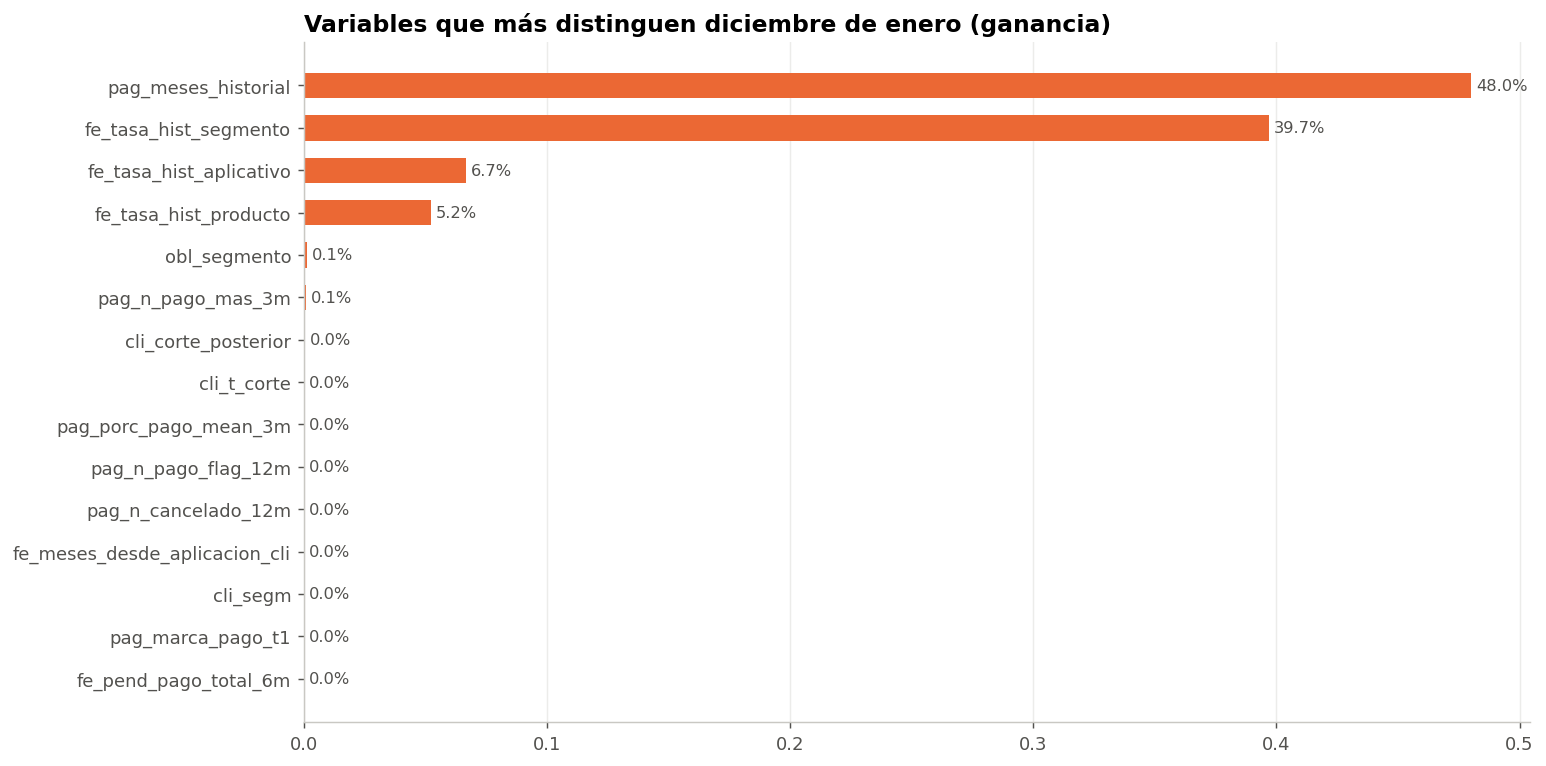

In [4]:
Xa = pd.concat([train.loc[mes == 202312, FEATS], test[FEATS]], ignore_index=True); ya = np.r_[np.zeros((mes == 202312).sum()), np.ones(len(test))]
rng = np.random.RandomState(SEED); idx = rng.permutation(len(Xa)); n_va = len(Xa) // 4
adv = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=200, colsample_bytree=0.8, random_state=SEED, verbose=-1, n_jobs=NJ)
adv.fit(Xa.iloc[idx[n_va:]], ya[idx[n_va:]], categorical_feature=CAT)
AUC_ADV = roc_auc_score(ya[idx[:n_va]], adv.predict_proba(Xa.iloc[idx[:n_va]])[:, 1])
imp_adv = pd.Series(adv.booster_.feature_importance("gain"), index=FEATS); imp_adv = (imp_adv / imp_adv.sum()).sort_values(ascending=False)
print(f"AUC adversario diciembre vs enero: {AUC_ADV:.3f}  (0,5 = indistinguibles)")
d = imp_adv.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(12, 6)); ax.barh(d.index, d.values, color=C_ORANGE, height=0.6)
for yv, v in zip(d.index, d.values): ax.text(v + 0.002, yv, f"{v:.1%}", va="center", fontsize=9, color=C_MUTED)
ax.set_title("Variables que más distinguen diciembre de enero (ganancia)"); ax.grid(axis="y", visible=False); plt.tight_layout(); fig_adv = fig; plt.show()

Prueba de exclusión: se quitan las variables que concentran más del 5 % de la separación y se compara el F1 temporal de un LightGBM de referencia (configuración del baseline) con y sin ellas. Se conserva el conjunto que dé mejor F1 promedio.

In [5]:
P_BASE = dict(objective="binary", learning_rate=0.05, num_leaves=63, min_child_samples=200, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0, random_state=SEED, verbose=-1, n_jobs=NJ)
def fp_lgb(params, n_max=3000):
    def f(Xtr, ytr, Xva, yva, w):
        m = lgb.LGBMClassifier(**params, n_estimators=n_max); m.fit(Xtr, ytr, sample_weight=w, eval_set=[(Xva, yva)], categorical_feature=[c for c in Xtr.columns if c in CAT], callbacks=[lgb.early_stopping(80, verbose=False)])
        return m.predict_proba(Xva)[:, 1], m.best_iteration_
    return f
SOSPECHOSAS = imp_adv[imp_adv > 0.05].index.tolist(); FEATS_SIN = [c for c in FEATS if c not in SOSPECHOSAS]
f1_con, det_con, _ = evaluar_temporal(fp_lgb(P_BASE), FEATS); f1_sin, det_sin, _ = evaluar_temporal(fp_lgb(P_BASE), FEATS_SIN)
print("Sospechosas (> 5 % de la separación):", SOSPECHOSAS)
print(f"F1 temporal promedio con todas ({len(FEATS)}): {f1_con:.4f} | sin sospechosas ({len(FEATS_SIN)}): {f1_sin:.4f}")
FEATS_T = FEATS_SIN if f1_sin > f1_con else FEATS; print("Conjunto elegido:", len(FEATS_T), "variables")
pd.concat([det_con.assign(conjunto="todas"), det_sin.assign(conjunto="sin sospechosas")]).round(4)

Sospechosas (> 5 % de la separación): ['pag_meses_historial', 'fe_tasa_hist_segmento', 'fe_tasa_hist_aplicativo', 'fe_tasa_hist_producto']
F1 temporal promedio con todas (100): 0.7024 | sin sospechosas (96): 0.7023
Conjunto elegido: 100 variables


,corte,F1,AUC,umbral,n_arboles,conjunto
0,202310,0.7045,0.7821,0.36,340,todas
1,202311,0.7094,0.7633,0.31,420,todas
2,202312,0.6933,0.7606,0.33,420,todas
0,202310,0.7049,0.7816,0.38,285,sin sospechosas
1,202311,0.7091,0.7627,0.33,305,sin sospechosas
2,202312,0.6928,0.7593,0.35,420,sin sospechosas


## 4. LightGBM con Optuna temporal

12 pruebas. Cada prueba entrena tres modelos (uno por corte) con parada temprana y se puntúa por el F1 promedio. El espacio favorece modelos regularizados: hojas grandes, submuestreo de columnas y regularización, que es lo que generalizó en el baseline.

In [6]:
prev_l = busquedas_previas("07_lgbm_temporal", 12)
g_l = grupo("07_lgbm_temporal", modelo="lightgbm", **TAGS, reanudado=str(prev_l is not None)); g_l.__enter__(); res_l = []
def obj_lgb(trial):
    params = {"objective": "binary", "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True), "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
              "min_child_samples": trial.suggest_int("min_child_samples", 50, 1000, log=True), "subsample": trial.suggest_float("subsample", 0.6, 1.0), "subsample_freq": 1,
              "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0), "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 20, log=True), "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
              "random_state": SEED, "verbose": -1, "n_jobs": NJ}
    t0 = time.time(); f1m, det, _ = evaluar_temporal(fp_lgb(params), FEATS_T)
    r = {**{k: v for k, v in params.items() if k not in ("objective", "subsample_freq", "random_state", "verbose", "n_jobs")}, "F1_prom": f1m, "F1_dic": det.F1.iloc[-1], "AUC_dic": det.AUC.iloc[-1], "seg": round(time.time() - t0)}; res_l.append(r)
    registrar_busqueda(trial.number + 1, {k: v for k, v in r.items() if k not in ("F1_prom", "F1_dic", "AUC_dic", "seg")}, {"f1_val": f1m, "f1_dic": r["F1_dic"], "auc_dic": r["AUC_dic"], "f1_oct": det.F1.iloc[0], "f1_nov": det.F1.iloc[1], "seg": r["seg"]})
    print(f"[{trial.number+1}/12] F1 prom {f1m:.4f} | dic {r['F1_dic']:.4f} | {r['seg']} s"); return f1m
if prev_l is None:
    st_l = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)); st_l.optimize(obj_lgb, n_trials=12); best_l = st_l.best_params
else:
    best_l = tipar(prev_l[0], {"num_leaves", "min_child_samples"}); res_l = [{"F1_prom": v} for v in prev_l[1]["metrics.f1_val"]]
    print(f"Búsqueda LightGBM reutilizada de MLflow ({len(prev_l[1])} pruebas). Mejor F1 prom previo: {prev_l[1]['metrics.f1_val'].max():.4f}")
P_LGB = {**best_l, "objective": "binary", "subsample_freq": 1, "random_state": SEED, "verbose": -1, "n_jobs": NJ}
F1_LGB, DET_LGB, p_dic_lgb = evaluar_temporal(fp_lgb(P_LGB), FEATS_T); res_l = pd.DataFrame(res_l)
print("\nMejor LightGBM:", best_l, f"| F1 prom {F1_LGB:.4f} | dic {DET_LGB.F1.iloc[-1]:.4f} (baseline dic 0.6931)")

Búsqueda LightGBM reutilizada de MLflow (12 pruebas). Mejor F1 prom previo: 0.7042



Mejor LightGBM: {'subsample': 0.8650089137415928, 'learning_rate': 0.021138128828094058, 'colsample_bytree': 0.5870266456536466, 'min_child_samples': 108, 'reg_lambda': 3.4052591913244687, 'num_leaves': 105, 'reg_alpha': 2.7335513967163982} | F1 prom 0.7042 | dic 0.6972 (baseline dic 0.6931)


## 5. XGBoost con Optuna temporal

8 pruebas con el mismo criterio. Profundidad acotada a 3 a 7 y mínimo de filas por hoja alto, para evitar la memorización que se vio en el 04.

In [7]:
def fp_xgb(params, n_max=3000):
    def f(Xtr, ytr, Xva, yva, w):
        m = xgb.XGBClassifier(**params, n_estimators=n_max, early_stopping_rounds=80, tree_method="hist", enable_categorical=True, objective="binary:logistic", eval_metric="logloss", random_state=SEED, n_jobs=NJ)
        m.fit(Xtr, ytr, sample_weight=w, eval_set=[(Xva, yva)], verbose=False); return m.predict_proba(Xva)[:, 1], m.best_iteration + 1
    return f
rid_l = registrar_final({k: v for k, v in P_LGB.items() if k not in ("objective", "subsample_freq", "random_state", "verbose", "n_jobs")}, {"f1_val": F1_LGB, "f1_dic": DET_LGB.F1.iloc[-1], "auc_dic": DET_LGB.AUC.iloc[-1], "n_arboles": DET_LGB.n_arboles.iloc[-1]}, DET_LGB.umbral.iloc[-1], FEATS_T)
g_l.__exit__(None, None, None)
prev_x = busquedas_previas("07_xgb_temporal", 6)
g_x = grupo("07_xgb_temporal", modelo="xgboost", **TAGS, reanudado=str(prev_x is not None)); g_x.__enter__(); res_x = []
def obj_xgb(trial):
    params = {"max_depth": trial.suggest_int("max_depth", 3, 7), "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.1, log=True), "min_child_weight": trial.suggest_int("min_child_weight", 20, 500, log=True),
              "subsample": trial.suggest_float("subsample", 0.6, 1.0), "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0), "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 20, log=True), "gamma": trial.suggest_float("gamma", 0, 3)}
    t0 = time.time(); f1m, det, _ = evaluar_temporal(fp_xgb(params), FEATS_T)
    r = {**params, "F1_prom": f1m, "F1_dic": det.F1.iloc[-1], "AUC_dic": det.AUC.iloc[-1], "seg": round(time.time() - t0)}; res_x.append(r)
    registrar_busqueda(trial.number + 1, params, {"f1_val": f1m, "f1_dic": r["F1_dic"], "auc_dic": r["AUC_dic"], "f1_oct": det.F1.iloc[0], "f1_nov": det.F1.iloc[1], "seg": r["seg"]})
    print(f"[{trial.number+1}/8] F1 prom {f1m:.4f} | dic {r['F1_dic']:.4f} | {r['seg']} s"); return f1m
if prev_x is None:
    st_x = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)); st_x.optimize(obj_xgb, n_trials=8); P_XGB = st_x.best_params
else:
    P_XGB = tipar(prev_x[0], {"max_depth", "min_child_weight"}); res_x = [{"F1_prom": v} for v in prev_x[1]["metrics.f1_val"]]
    print(f"Búsqueda XGBoost reutilizada de MLflow ({len(prev_x[1])} pruebas). Mejor F1 prom previo: {prev_x[1]['metrics.f1_val'].max():.4f}")
F1_XGB, DET_XGB, p_dic_xgb = evaluar_temporal(fp_xgb(P_XGB), FEATS_T); res_x = pd.DataFrame(res_x)
rid_x = registrar_final(P_XGB, {"f1_val": F1_XGB, "f1_dic": DET_XGB.F1.iloc[-1], "auc_dic": DET_XGB.AUC.iloc[-1], "n_arboles": DET_XGB.n_arboles.iloc[-1]}, DET_XGB.umbral.iloc[-1], FEATS_T)
g_x.__exit__(None, None, None)
print("\nMejor XGBoost:", P_XGB, f"| F1 prom {F1_XGB:.4f} | dic {DET_XGB.F1.iloc[-1]:.4f}")

Búsqueda XGBoost reutilizada de MLflow (6 pruebas). Mejor F1 prom previo: 0.7033



Mejor XGBoost: {'subsample': 0.8736932106048627, 'min_child_weight': 27, 'learning_rate': 0.032654713909375875, 'colsample_bytree': 0.6640914962437607, 'reg_lambda': 0.7843006551565, 'max_depth': 7, 'gamma': 1.4855307303338106} | F1 prom 0.7033 | dic 0.6964


## 6. Peso por recencia

Enero se parece más a diciembre que a agosto. Se prueba dar más peso a las filas recientes (agosto 0,4 → noviembre 1,0, lineal) con el mejor LightGBM. Se adopta si mejora el F1 temporal promedio.

In [8]:
orden = {202308: 0, 202309: 1, 202310: 2, 202311: 3, 202312: 4, 202401: 5}  # 202401 solo como mes objetivo del reentreno final
def pesos_recencia(m_val):
    k = mes.map(orden).to_numpy().astype(float); k_max = orden[m_val] - 1
    return np.where(k <= k_max, 0.4 + 0.6 * k / max(k_max, 1), 1.0)
# evaluar_temporal usa un solo vector de pesos; se calcula por corte dentro de un envoltorio
def evaluar_con_recencia(fp, cols):
    det = []; p_dic = None
    for m in CORTES:
        Xtr, ytr, Xva, yva, mtr = fold(m, cols); w = pesos_recencia(m)[mtr.values]; p, n = fp(Xtr, ytr, Xva, yva, w); u, f1 = mejor_umbral(yva, p)
        det.append({"corte": m, "F1": f1, "AUC": roc_auc_score(yva, p), "umbral": u, "n_arboles": n});
        if m == 202312: p_dic = p
    det = pd.DataFrame(det); return float(det.F1.mean()), det, p_dic
F1_REC, DET_REC, p_dic_rec = evaluar_con_recencia(fp_lgb(P_LGB), FEATS_T)
USAR_PESOS = F1_REC > F1_LGB
print(f"LightGBM sin pesos: F1 prom {F1_LGB:.4f} (dic {DET_LGB.F1.iloc[-1]:.4f}) | con recencia: {F1_REC:.4f} (dic {DET_REC.F1.iloc[-1]:.4f}) -> {'se adoptan' if USAR_PESOS else 'no se adoptan'}")
anexar(rid_l, metricas={"f1_val_recencia": F1_REC, "f1_dic_recencia": DET_REC.F1.iloc[-1]}, tags={"recencia_adoptada": str(USAR_PESOS)})
if USAR_PESOS: p_dic_lgb = p_dic_rec; DET_LGB = DET_REC

LightGBM sin pesos: F1 prom 0.7042 (dic 0.6972) | con recencia: 0.7041 (dic 0.6976) -> no se adoptan


## 7. Ensamble y umbrales en diciembre

Con los modelos entrenados hasta noviembre: LightGBM, XGBoost y CatBoost (hiperparámetros del notebook 04). Promedio de probabilidades y umbral elegido en diciembre. Además, umbral separado para obligaciones con y sin historial en trtest.

In [9]:
Xtr, ytr, Xva, yva, mtr = fold(202312, FEATS_T); w = pesos_recencia(202312)[mtr.values] if USAR_PESOS else None
def para_cat(df):
    d = df.copy()
    for c in [c for c in d.columns if c in CAT]: d[c] = d[c].astype(str).replace("nan", "NA")
    return d
CAT_T = [c for c in FEATS_T if c in CAT]
t0 = time.time()
cb = CatBoostClassifier(depth=6, learning_rate=0.06, l2_leaf_reg=1, random_strength=0.5, iterations=1500, od_type="Iter", od_wait=60, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=NJ)
cb.fit(Pool(para_cat(Xtr), ytr, cat_features=CAT_T, weight=w), eval_set=Pool(para_cat(Xva), yva, cat_features=CAT_T), use_best_model=True)
p_dic_cb = cb.predict_proba(Pool(para_cat(Xva), cat_features=CAT_T))[:, 1]; print(f"CatBoost hasta nov -> dic: {cb.get_best_iteration()+1} árboles, {time.time()-t0:.0f} s")

cands = {"LightGBM": p_dic_lgb, "XGBoost": p_dic_xgb, "CatBoost": p_dic_cb, "Ensamble LGB+XGB": (p_dic_lgb + p_dic_xgb) / 2, "Ensamble 3": (p_dic_lgb + p_dic_xgb + p_dic_cb) / 3}
tabla = {}
for k, p in cands.items():
    u, f1 = mejor_umbral(yva, p); tabla[k] = metricas(yva, p, u)
tabla = pd.DataFrame(tabla).T; tabla.loc["Baseline LGB (nb 03)"] = {"umbral": 0.35, "AUC": 0.7589, "F1": 0.6931, "precisión": 0.5980, "recall": 0.8242, "% pred 1": 0.645}
tabla.round(4)

CatBoost hasta nov -> dic: 748 árboles, 413 s


,umbral,AUC,F1,precisión,recall,% pred 1
LightGBM,0.33,0.7659,0.6972,0.5963,0.8393,0.6590
XGBoost,0.34,0.7640,0.6964,0.5956,0.8384,0.6592
CatBoost,0.33,0.7603,0.6930,0.5891,0.8415,0.6689
Ensamble LGB+XGB,0.33,0.7656,0.6969,0.5929,0.8451,0.6674
Ensamble 3,0.35,0.7654,0.6968,0.6040,0.8232,0.6381
Baseline LGB (nb 03),0.35,0.7589,0.6931,0.5980,0.8242,0.6450


Mejor en diciembre: LightGBM | umbral global 0.33 -> F1 0.6972
Umbral por subpoblación: con historial 0.33 (47% de dic), sin historial 0.37 -> F1 0.6974 -> no se adopta


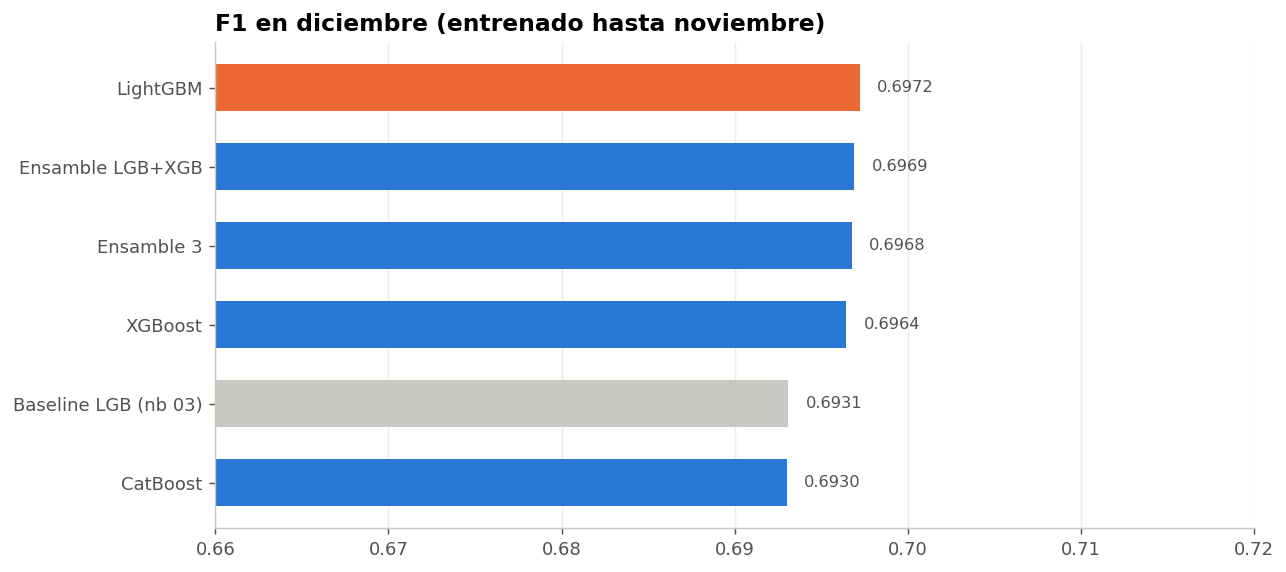

In [10]:
MEJOR = tabla.drop(index="Baseline LGB (nb 03)").F1.idxmax(); p_best = cands[MEJOR]; U_GLOBAL, F1_GLOBAL = mejor_umbral(yva, p_best)
con_hist = (Xva["lag_n_meses_vistos"] > 0).to_numpy()
u_con, _ = mejor_umbral(yva[con_hist], p_best[con_hist]); u_sin, _ = mejor_umbral(yva[~con_hist], p_best[~con_hist])
pred_seg = np.where(con_hist, p_best >= u_con, p_best >= u_sin).astype(int); F1_SEG = f1_score(yva, pred_seg)
USAR_SEG = F1_SEG > F1_GLOBAL + 0.001
print(f"Mejor en diciembre: {MEJOR} | umbral global {U_GLOBAL:.2f} -> F1 {F1_GLOBAL:.4f}")
print(f"Umbral por subpoblación: con historial {u_con:.2f} ({con_hist.mean():.0%} de dic), sin historial {u_sin:.2f} -> F1 {F1_SEG:.4f} -> {'se adopta' if USAR_SEG else 'no se adopta'}")
fig, ax = plt.subplots(figsize=(10, 4.5)); d = tabla.F1.sort_values()
ax.barh(d.index, d.values, color=[C_ORANGE if i == MEJOR else (C_GRAY if "Baseline" in i else C_BLUE) for i in d.index], height=0.6)
for yv, v in zip(d.index, d.values): ax.text(v + 0.001, yv, f"{v:.4f}", va="center", fontsize=9, color=C_MUTED)
ax.set_xlim(0.66, max(d.max() + 0.02, 0.72)); ax.set_title("F1 en diciembre (entrenado hasta noviembre)"); ax.grid(axis="y", visible=False); plt.tight_layout(); fig_f1 = fig; plt.show()

## 8. Modelo final y Kaggle

Los modelos del mejor candidato se reentrenan con los cinco meses (número de árboles del corte de diciembre) y califican `oot` con el umbral fijado en diciembre. Archivos `submission_v4.csv` y `resultado_prueba_v4.csv`. Registro en MLflow como grupo `07_ensamble_final`.

In [11]:
w_all = pesos_recencia(202401) if USAR_PESOS else None
X_all, X_oot = train[FEATS_T], test[FEATS_T]; probs = {}
if "LightGBM" in MEJOR or "Ensamble" in MEJOR:
    m = lgb.LGBMClassifier(**P_LGB, n_estimators=int(DET_LGB.n_arboles.iloc[-1])); m.fit(X_all, y, sample_weight=w_all, categorical_feature=CAT_T); probs["LightGBM"] = m.predict_proba(X_oot)[:, 1]; m.booster_.save_model(str(ROOT / "models" / "lgbm_v4.txt"))
if "XGBoost" in MEJOR or "Ensamble" in MEJOR:
    m = xgb.XGBClassifier(**P_XGB, n_estimators=int(DET_XGB.n_arboles.iloc[-1]), tree_method="hist", enable_categorical=True, objective="binary:logistic", random_state=SEED, n_jobs=NJ); m.fit(X_all, y, sample_weight=w_all); probs["XGBoost"] = m.predict_proba(X_oot)[:, 1]; m.save_model(str(ROOT / "models" / "xgb_v4.json"))
if "CatBoost" in MEJOR or MEJOR == "Ensamble 3":
    m = CatBoostClassifier(depth=6, learning_rate=0.06, l2_leaf_reg=1, random_strength=0.5, iterations=cb.get_best_iteration() + 1, loss_function="Logloss", random_seed=SEED, verbose=False, thread_count=NJ)
    m.fit(Pool(para_cat(X_all), y, cat_features=CAT_T, weight=w_all)); probs["CatBoost"] = m.predict_proba(Pool(para_cat(X_oot), cat_features=CAT_T))[:, 1]; m.save_model(str(ROOT / "models" / "catboost_v4.cbm"))
p_oot = np.mean(list(probs.values()), axis=0)
hist_oot = (test["lag_n_meses_vistos"] > 0).to_numpy()
pred_oot = (np.where(hist_oot, p_oot >= u_con, p_oot >= u_sin) if USAR_SEG else (p_oot >= U_GLOBAL)).astype(int)
ss = pd.read_csv(DATA / "sample_submission.csv", usecols=["ID"])
res = ss.merge(pd.DataFrame({"ID": test.ID.astype(str), "Prob_uno": p_oot, "var_rpta_alt": pred_oot}), on="ID", how="left"); assert res.Prob_uno.notna().all() and len(res) == len(ss)
res[["ID", "var_rpta_alt"]].to_csv(OUT / "submission_v4.csv", index=False); res[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba_v4.csv", index=False, encoding="utf-8")
print(f"Final: {MEJOR} ({', '.join(probs)}) | umbral {'por subpoblación' if USAR_SEG else f'{U_GLOBAL:.2f}'} | % predicho 1 en oot: {res.var_rpta_alt.mean():.3f} | prob media {res.Prob_uno.mean():.3f}")

Final: LightGBM (LightGBM) | umbral 0.33 | % predicho 1 en oot: 0.644 | prob media 0.453


In [12]:
with grupo("07_ensamble_final", modelo=MEJOR, **TAGS):
    rid_e = registrar_final({"componentes": ", ".join(probs), "lgb": str(P_LGB), "xgb": str(P_XGB), "recencia": USAR_PESOS, "umbral_subpoblacion": USAR_SEG, "adversarial_auc": round(AUC_ADV, 3), "sospechosas_excluidas": str(SOSPECHOSAS if FEATS_T is not FEATS else [])},
                           {"f1_dic": F1_SEG if USAR_SEG else F1_GLOBAL, "f1_dic_global": F1_GLOBAL, "auc_dic": tabla.loc[MEJOR, "AUC"], "precision_dic": tabla.loc[MEJOR, "precisión"], "recall_dic": tabla.loc[MEJOR, "recall"], "pct_pred_1_oot": res.var_rpta_alt.mean(), "umbral_con_hist": u_con, "umbral_sin_hist": u_sin},
                           U_GLOBAL, FEATS_T, figuras={"f1_diciembre": fig_f1, "adversarial": fig_adv}, tags={"ganador_07": "True"})
    import mlflow; mlflow.log_artifact(str(OUT / "submission_v4.csv"), artifact_path="kaggle")
res_l.to_csv(OUT / "busqueda_07_lgb.csv", index=False); res_x.to_csv(OUT / "busqueda_07_xgb.csv", index=False); tabla.to_csv(OUT / "comparacion_07_diciembre.csv")
resumen("grupo")[["run", "mejor_f1_val", "f1_val", "f1_dic", "f1_test", "f1_kaggle_publico"]]

,run,mejor_f1_val,f1_val,f1_dic,f1_test,f1_kaggle_publico
0,03_lightgbm_baseline,NaN,0.693114,NaN,NaN,0.70694
1,04_catboost,0.729200,0.729200,NaN,0.733300,0.70379
2,04_xgboost,0.743300,0.743300,NaN,0.746800,0.70450
3,05_logistica,0.690500,0.690500,NaN,0.695400,NaN
4,05_svm_lineal,0.690100,0.690100,NaN,0.694900,NaN
5,05_svm_rbf,0.696000,0.696000,NaN,0.699000,NaN
6,06_catboost_fe,0.735573,0.735573,NaN,0.737476,NaN
7,06_xgboost_fe,0.755312,0.753710,0.696403,0.757232,NaN
8,07_ensamble_final,NaN,NaN,0.697219,NaN,NaN
9,07_lgbm_temporal,NaN,0.704230,0.697219,NaN,NaN
